#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import KMRF class
from kmrf import KMRF
from KMRF_training_config import *

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully
  Pandas version: 2.3.3
  NumPy version: 2.3.4


## 1. Configure KMRF Model

In [2]:
# Create DataFrame of asset names
asset_names_df = pd.DataFrame({
    'Investment Universe ETFs': get_assets_by_class('universe') + ['']*7,
    'US Equity ETFs': get_assets_by_class('us_equity'),
    'Commodities': get_assets_by_class('commodity') + ['']*5,
    'International Equity ETFs': get_assets_by_class('int_equity') + ['']*11,

})
# asset_names_df
get_assets_by_class('universe')

['IVV - iShares Core S&P 500 ETF',
 'IJH - iShares Core S&P Mid-Cap ETF',
 'IWM - iShares Russell 2000 ETF',
 'EFA - iShares MSCI EAFE ETF',
 'EEM - iShares MSCI Emerging Markets ETF',
 'AGG - iShares Core U.S. Aggregate Bond ETF',
 'SPTL - SPDR Portfolio Long Term Treasury ETF',
 'HYG - iShares iBoxx $ High Yield Corporate Bond ETF',
 'SPBO - SPDR Portfolio Corporate Bond ETF',
 'IYR - iShares U.S. Real Estate ETF',
 'DBC - Invesco DB Commodity Index Tracking Fund',
 'GLD - SPDR Gold Shares']

In [3]:
TRAINING_CONFIG = KMRF_Training_Config(
    asset_name='IVV - iShares Core S&P 500 ETF',
    classification_type='original',
    use_data_type='master',
    feature_window_size=1
)
cross_assets_to_include = [] # empty means all (only referring to universe assets)

## 2. Initialize KMRF Model

In [4]:
# Initialize KMRF model with new features
model = KMRF(
    asset_class=TRAINING_CONFIG.get_asset_class(),
    asset_name=TRAINING_CONFIG.get_asset_name(),
    classification_type=TRAINING_CONFIG.get_classification_type(),
    end_date=TRAINING_CONFIG.get_date_ranges()['end_date'],
    use_data_type=TRAINING_CONFIG.get_use_data_type(),
    feature_window_size=TRAINING_CONFIG.get_feature_window_size(),  
    feature_asset_classes=TRAINING_CONFIG.get_cross_asset_features(),
    cross_asset_specific=cross_assets_to_include,
    rf_params=TRAINING_CONFIG.get_rf_params()
)

print("\n" + "="*80)
print("KMRF MODEL INITIALIZED")
print("="*80)

KMRF model initialized
  Asset: IVV - iShares Core S&P 500 ETF
  Asset class: universe
  Classification type: original
  End date: 20190101
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/universe/20190101
  Validation period: 2019-02-01 to 2021-12-30
  Test start: 2022-02-01
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: ['universe']
  Custom RF parameters: {'n_estimators': 220, 'max_depth': 13, 'min_samples_split': 76, 'min_samples_leaf': 95, 'max_samples': 0.3649, 'max_features': 0.2481, 'min_weight_fraction_leaf': 0.0454, 'random_state': 1010, 'n_jobs': -1, 'class_weight': 'balanced'}

KMRF MODEL INITIALIZED


## 3. Run Training Pipeline

In [5]:
model.pipeline(optimize=False)


KMRF PIPELINE FOR IVV - iShares Core S&P 500 ETF
Asset Class: universe
Classification Type: original
Data Type: master
Feature Asset Classes: ['universe']
Feature Window Size: 1

[Step 1/10] Loading Data...

Loading data from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
Loaded data for: IVV - iShares Core S&P 500 ETF
  Rows: 6397
  Columns: 95
  Date range: 2000-05-19 00:00:00 to 2025-10-24 00:00:00

[Step 2/10] Computing Features...

Extracting pre-computed features for IVV - iShares Core S&P 500 ETF...
  Features shape: (6397, 95)

[Step 3/10] Loading KAMA+MSR Labels...

LOADING KAMA+MSR LABELS FOR IVV - iShares Core S&P 500 ETF
Loading from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_label_df.csv
✓ Loaded labels for: IVV - iShares Core S&P 500 ETF
  Label date range: 2000-06-06 00:00:00 to 2018-12-31 00:00:00
  Total periods: 4672

  Original 4-regime distribution:
    0 -   LV Bullish:  3236 ( 69.3

## 4. Generate & Visualize Predictions


GENERATING VALIDATION PREDICTIONS

Generating predictions...
  Input shape: (735, 266)
  Using pre-selected features: 266
✓ Generated probability predictions: (735, 4)

Prediction probabilities shape: (735, 4)
Columns: ['P(LV_Bull)', 'P(LV_Bear)', 'P(HV_Bull)', 'P(HV_Bear)']

Sample predictions (first 10 days):
            P(LV_Bull)  P(LV_Bear)  P(HV_Bull)  P(HV_Bear)
date                                                      
2019-02-01    0.208733    0.616025    0.096148    0.079094
2019-02-04    0.244719    0.621370    0.064123    0.069787
2019-02-05    0.319745    0.547952    0.074341    0.057963
2019-02-06    0.425318    0.412575    0.112819    0.049288
2019-02-07    0.463975    0.404254    0.085952    0.045819
2019-02-08    0.259268    0.569340    0.102112    0.069279
2019-02-11    0.295794    0.569674    0.071981    0.062551
2019-02-12    0.322069    0.546659    0.072396    0.058876
2019-02-13    0.507645    0.355883    0.097065    0.039406
2019-02-14    0.534611    0.353837   

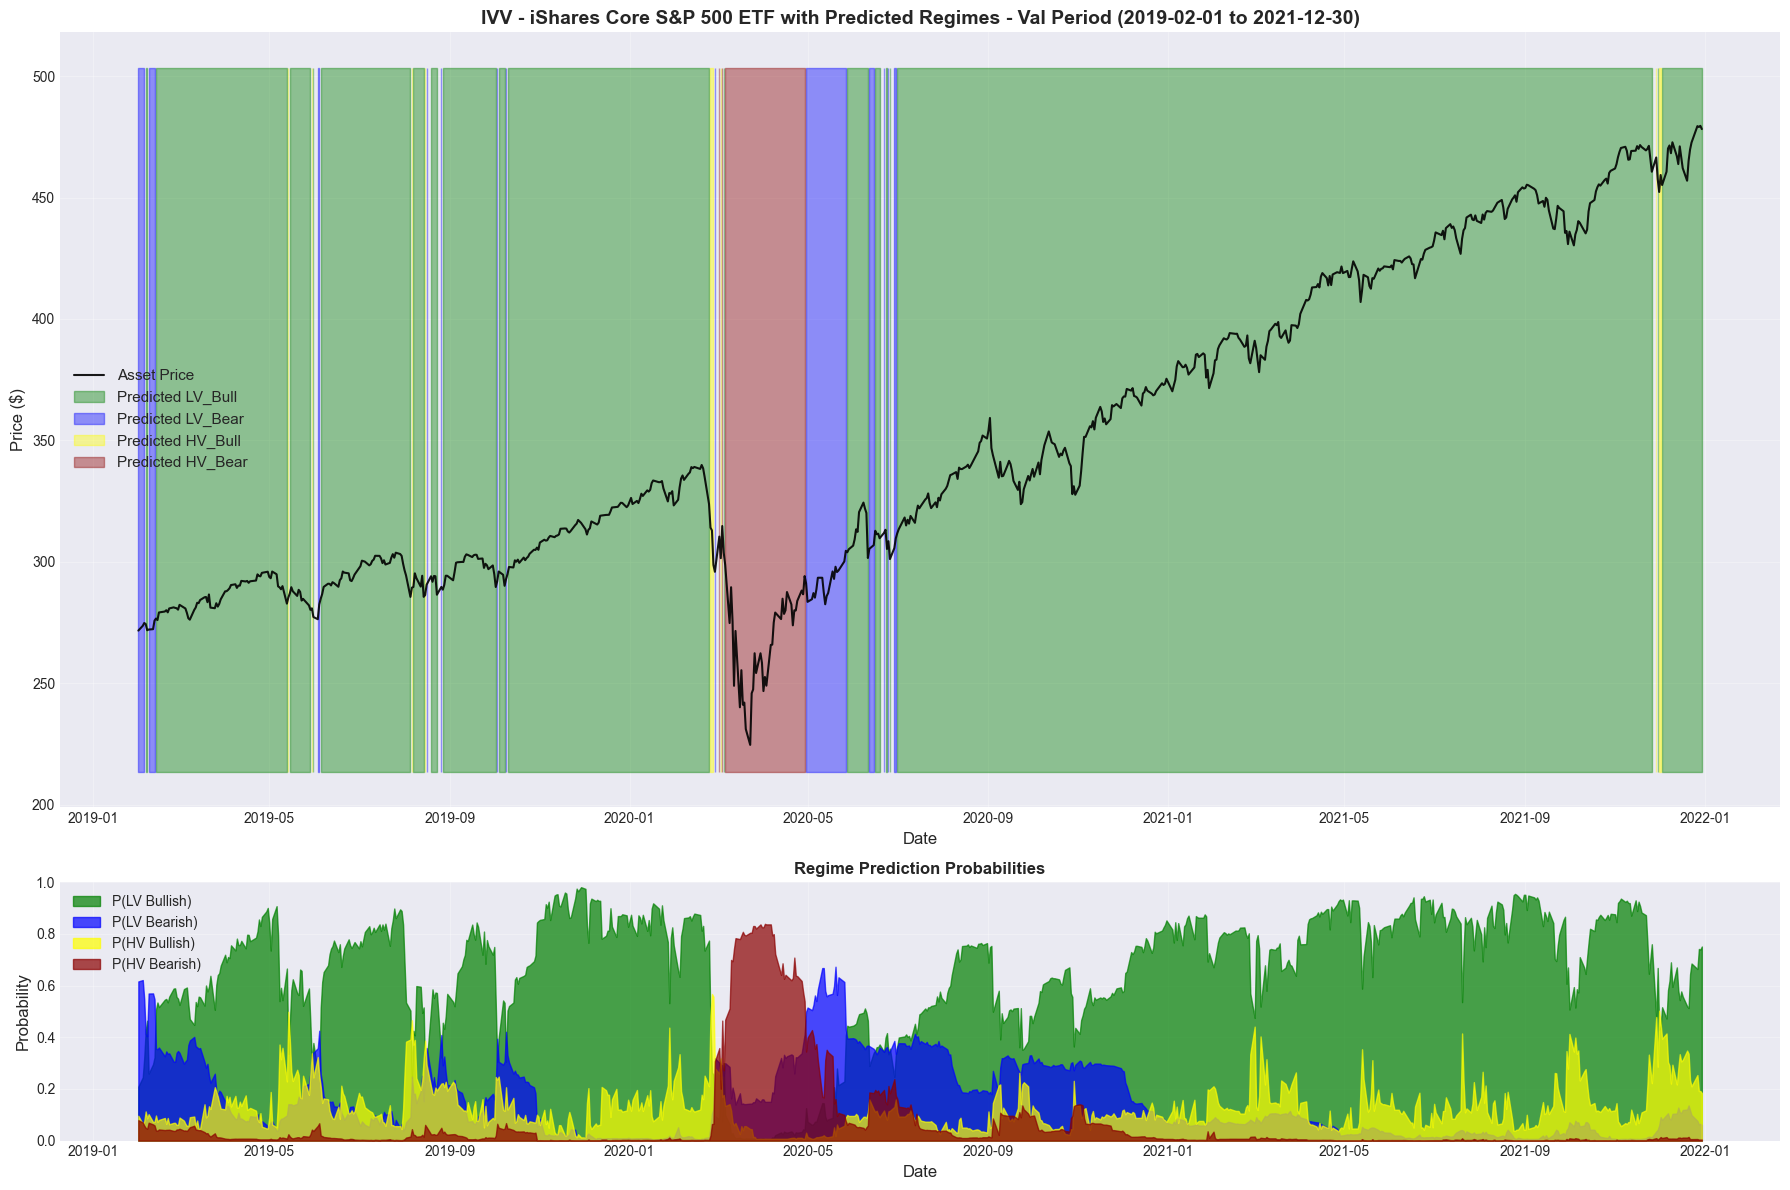

In [6]:
# Make predictions on validation set
print("\n" + "="*80)
print("GENERATING VALIDATION PREDICTIONS")
print("="*80)

y_val_pred_proba = model.predict(test_or_val='val')

print(f"\nPrediction probabilities shape: {y_val_pred_proba.shape}")
print(f"Columns: {list(y_val_pred_proba.columns)}")
print(f"\nSample predictions (first 10 days):")
print(y_val_pred_proba.head(10))

# Visualize predictions
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)
model.viz_predictions(test_or_val='val')

## 5. Save Model

In [7]:
path = f'saved_models/KMRF_new/{model.classification_type}/{model.asset_class}/'
path += f'{model.asset_name.replace(" ", "_")}_KMRF_model.pkl'
model.save_model(path)


Saving model to: saved_models/KMRF_new/original/universe/IVV_-_iShares_Core_S&P_500_ETF_KMRF_model.pkl
  Asset: IVV - iShares Core S&P 500 ETF
  Asset class: universe
  Classification type: original
  Features: 266
  Training samples: 4420
✓ Model saved successfully


PosixPath('saved_models/KMRF_new/original/universe/IVV_-_iShares_Core_S&P_500_ETF_KMRF_model.pkl')